# 04 — Model Comparison

**This notebook does not retrain anything.** It loads the predictions and
metrics saved by `02_sarima.ipynb` (`results/pred_sarima_sq*.pkl`) and
`03_lstm_tcn.ipynb` (`results/pred_lstm_sq*.pkl`, `results/pred_tcn_sq*.pkl`)
and produces:
1. the 9 actual-vs-predicted plots (3 squares × 3 models)
2. the 3 per-square MAE/MAPE/RMSE tables
3. the timing comparison table (fit/predict time per model/square)
4. one cross-model, cross-square summary plot

Run `02_sarima.ipynb` and `03_lstm_tcn.ipynb` first if `results/pred_*.pkl`
files are missing.

In [11]:
import glob
import os
import pickle
import re
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, ".")

import common

os.makedirs("figures", exist_ok=True)
os.makedirs("results", exist_ok=True)

meta = common.load_target_squares_meta()
squares = meta["top3_squares"]

PRED_PATTERN = re.compile(r"pred_(sarima|lstm|tcn)_sq(\d+)\.pkl")
MODEL_LABELS = {"sarima": "SARIMA", "lstm": "LSTM", "tcn": "TCN"}

# These pickles are written by 02_sarima.ipynb / 03_lstm_tcn.ipynb in this same
# repo (never from an external/untrusted source), mirroring the original
# codebase's experiments/results/*.pkl -- safe to unpickle here.
results = {}
for path in sorted(glob.glob("results/pred_*_sq*.pkl")):
    match = PRED_PATTERN.search(os.path.basename(path))
    if not match:
        continue
    model_key, square_id = match.group(1), int(match.group(2))
    with open(path, "rb") as f:
        results[(MODEL_LABELS[model_key], square_id)] = pickle.load(f)

print(f"Loaded {len(results)} (model, square) result files: "
      f"{sorted(set(k[0] for k in results))} x {sorted(set(k[1] for k in results))}")
missing = [(m, sq) for m in ["SARIMA", "LSTM", "TCN"] for sq in squares if (m, sq) not in results]
if missing:
    print(f"WARNING: missing results for {missing} -- run the corresponding notebook(s) first.")

Loaded 9 (model, square) result files: ['LSTM', 'SARIMA', 'TCN'] x [5059, 5161, 5259]


## 1. Actual-vs-predicted plots (9 total: 3 squares × 3 models)

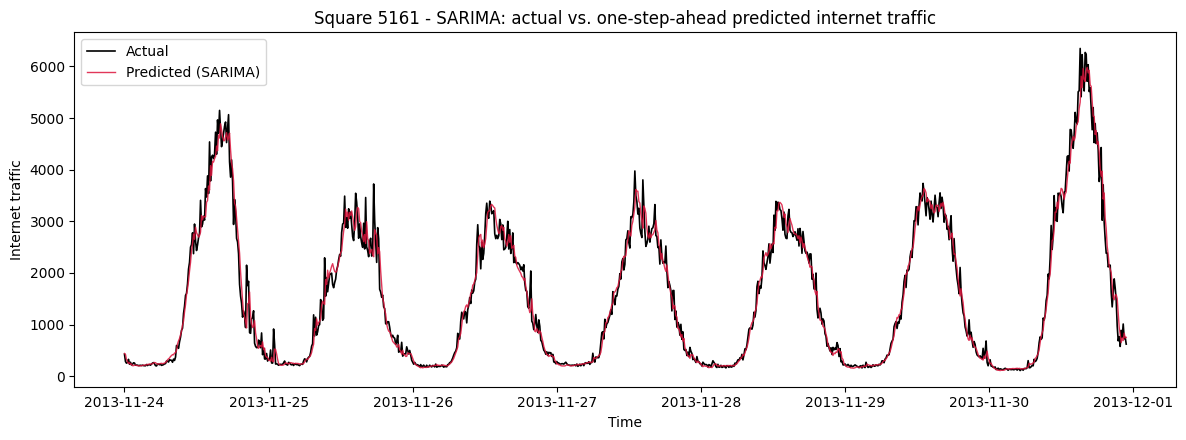

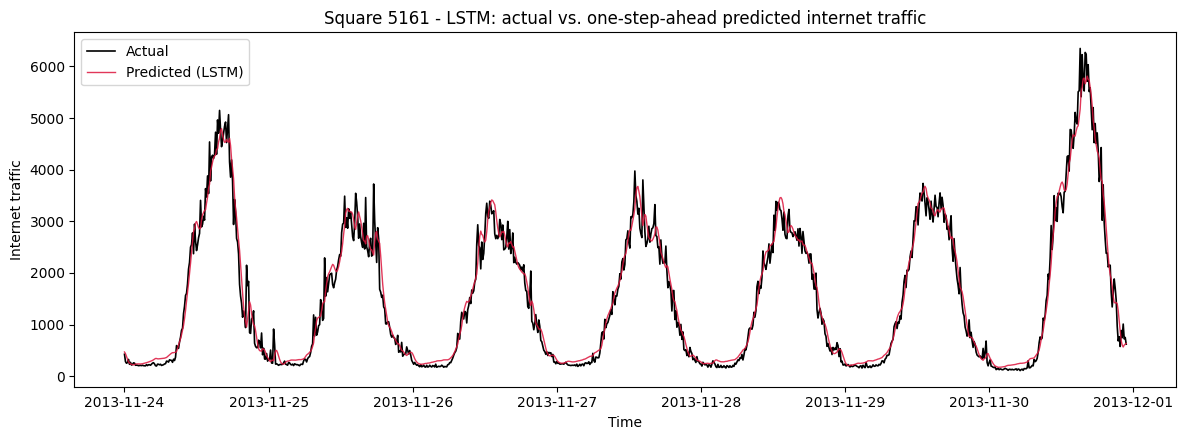

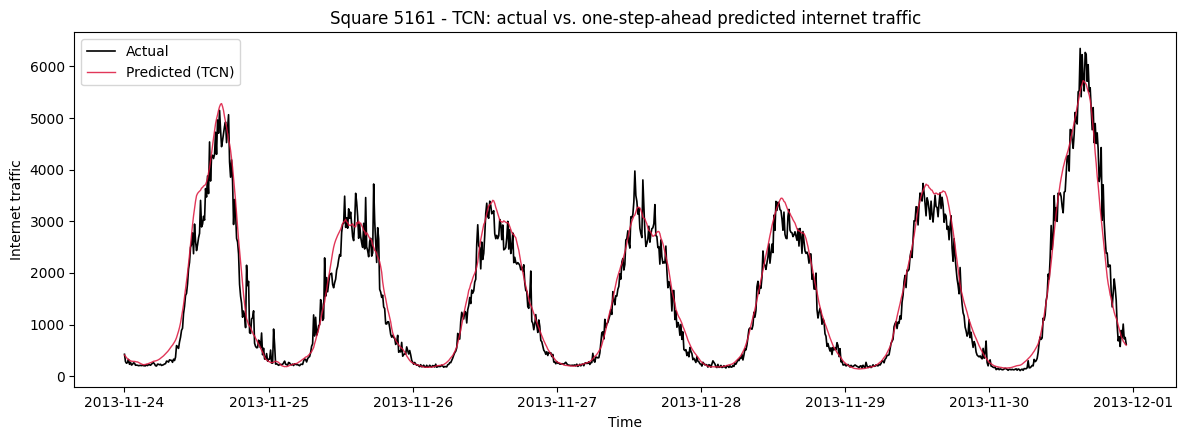

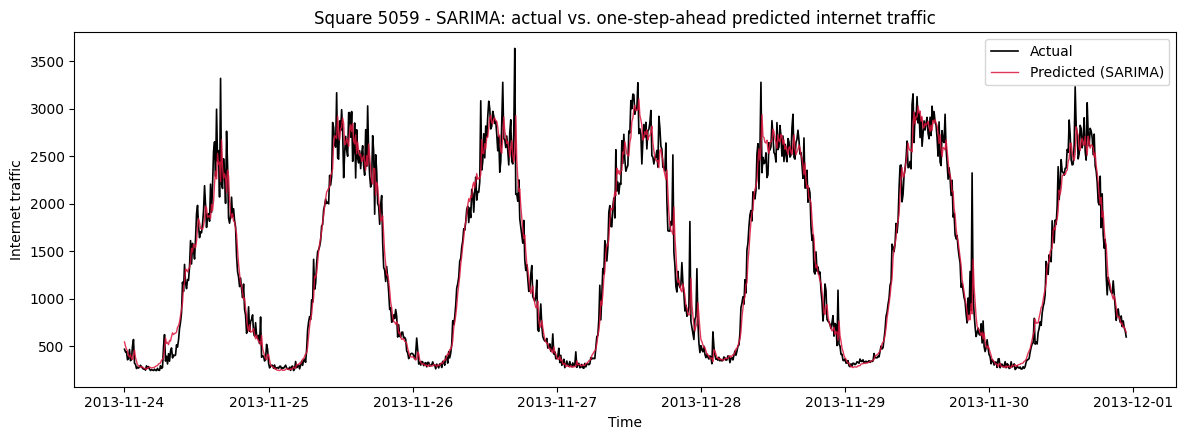

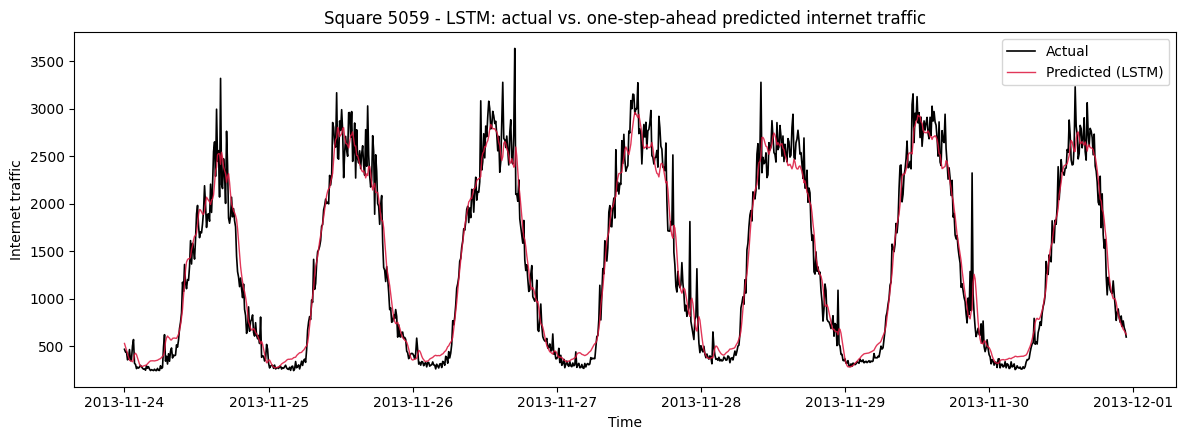

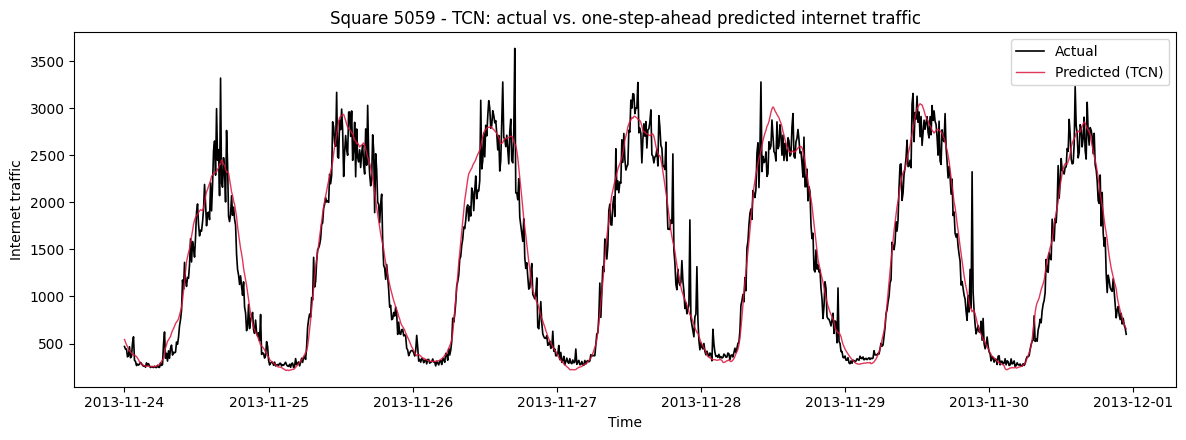

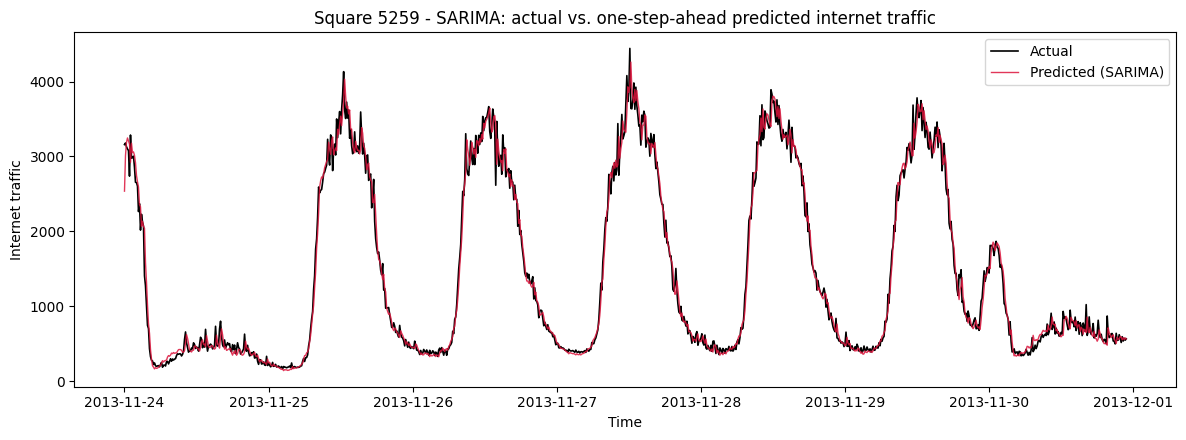

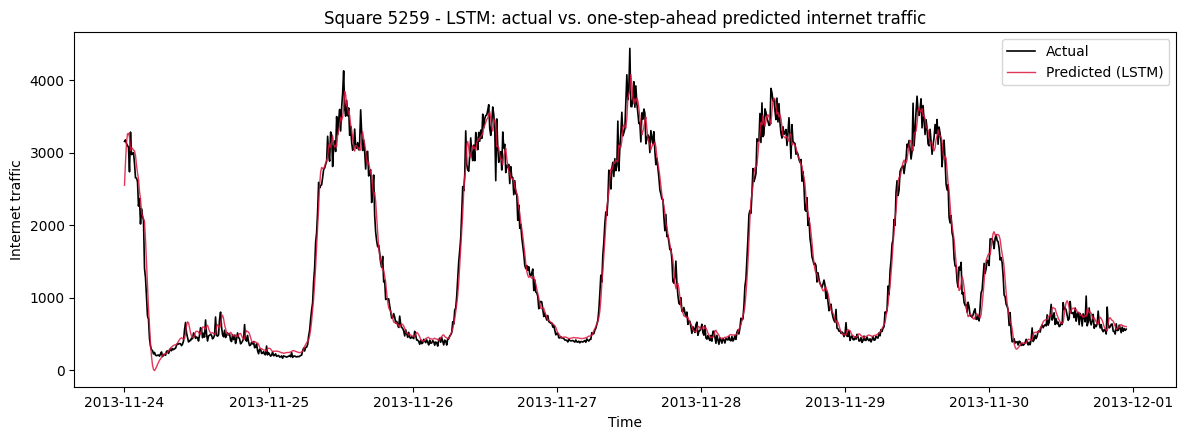

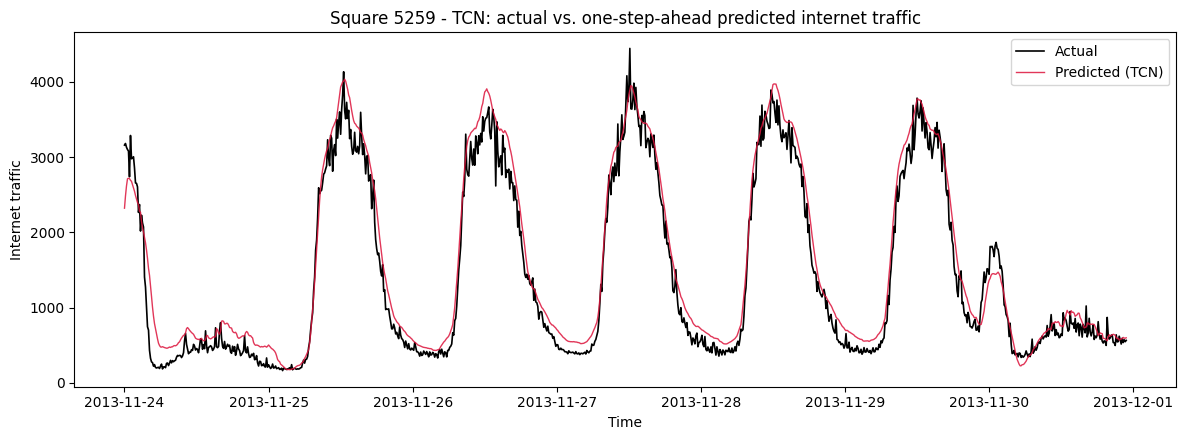

In [7]:
def plot_square_model(actual_index, actual_values, pred_index, preds, square_id, model_name):
    fig, ax = plt.subplots(figsize=(12, 4.5))
    ax.plot(actual_index, actual_values, label="Actual", color="black", linewidth=1.2)
    ax.plot(pred_index, preds, label=f"Predicted ({model_name})", color="crimson", linewidth=1.0, alpha=0.85)
    ax.set_title(f"Square {square_id} - {model_name}: actual vs. one-step-ahead predicted internet traffic")
    ax.set_xlabel("Time"); ax.set_ylabel("Internet traffic")
    ax.legend()
    fig.tight_layout()
    fig.savefig(f"figures/pred_sq{square_id}_{model_name}.png", dpi=150, bbox_inches="tight")
    plt.show()


for square_id in squares:
    for model_name in ["SARIMA", "LSTM", "TCN"]:
        r = results.get((model_name, square_id))
        if r is None:
            continue
        plot_square_model(r["eval_index"], r["actual"], r["eval_index"], r["predictions"], square_id, model_name)

## 2. Per-square performance tables (MAE / MAPE / RMSE)

In [8]:
for square_id in squares:
    print(f"--- Square {square_id} ---")
    rows = {model_name: results[(model_name, square_id)]["metrics"]
            for model_name in ["SARIMA", "LSTM", "TCN"] if (model_name, square_id) in results}
    table = pd.DataFrame(rows).T[["MAE", "MAPE", "RMSE"]].sort_values("RMSE")
    table.to_csv(f"results/model_performance_square_{square_id}.csv")
    display(table)

--- Square 5161 ---


,MAE,MAPE,RMSE
SARIMA,143.959559,12.249758,222.857456
LSTM,168.734843,21.153433,237.812234
TCN,188.932879,18.486218,275.795026


--- Square 5059 ---


,MAE,MAPE,RMSE
SARIMA,124.089507,10.712199,188.133188
LSTM,140.544708,14.882320,199.351886
TCN,141.233099,12.539091,201.705760


--- Square 5259 ---


,MAE,MAPE,RMSE
SARIMA,101.813625,9.367653,147.611080
LSTM,109.838305,11.696053,153.679553
TCN,195.309411,25.646242,240.502788


## 3. Timing comparison table

In [9]:
timing_rows = []
for (model_name, square_id), r in results.items():
    timing_rows.append({
        "square_id": square_id, "model": model_name,
        "fit_time_s": r["fit_time_s"], "predict_time_total_s": r["predict_time_s"],
        "predict_time_per_step_ms": r["predict_time_per_step_ms"],
    })
timing_df = pd.DataFrame(timing_rows).sort_values(["square_id", "model"]).reset_index(drop=True)
timing_df.to_csv("results/timing_stats.csv", index=False)
timing_df

,square_id,model,fit_time_s,predict_time_total_s,predict_time_per_step_ms
0,5059,LSTM,124.173600,0.574539,0.573393
1,5059,SARIMA,6.442568,51.433386,51.330725
2,5059,TCN,66.547536,0.636393,0.635123
3,5161,LSTM,110.347033,0.495527,0.494538
4,5161,SARIMA,2.979361,51.104110,51.002105
5,5161,TCN,68.773501,0.701311,0.699911
6,5259,LSTM,134.003789,0.564405,0.563278
7,5259,SARIMA,8.142848,52.595037,52.490057
8,5259,TCN,71.179550,0.631640,0.630380


## 4. Cross-model, cross-square summary

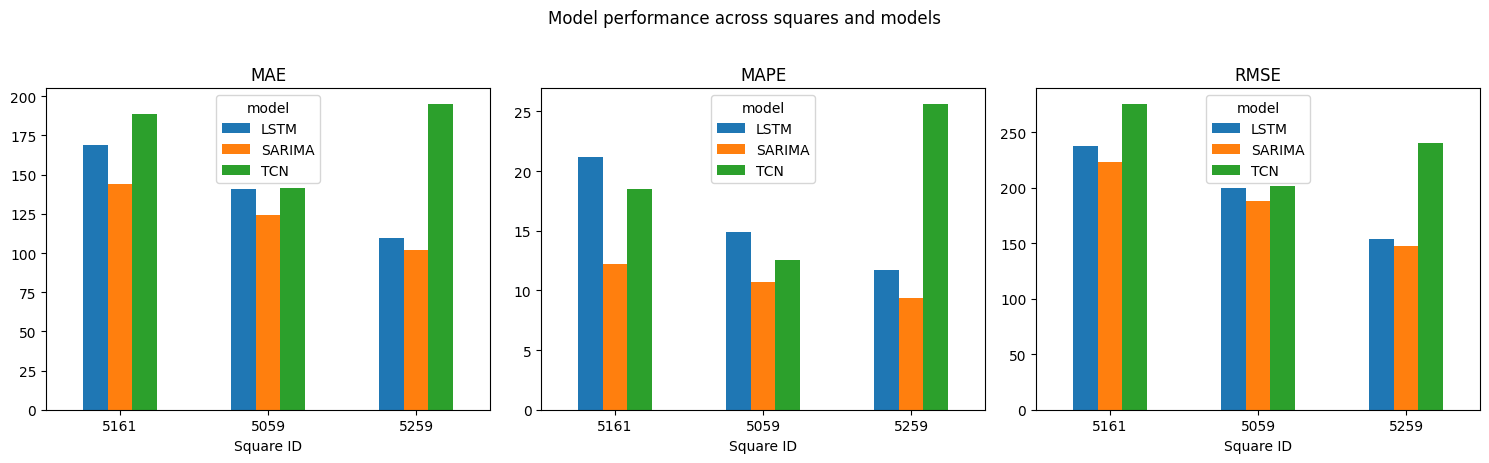

,square_id,model,MAE,RMSE,MAPE
0,5059,LSTM,140.544708,199.351886,14.882320
1,5161,LSTM,168.734843,237.812234,21.153433
2,5259,LSTM,109.838305,153.679553,11.696053
3,5059,SARIMA,124.089507,188.133188,10.712199
4,5161,SARIMA,143.959559,222.857456,12.249758
5,5259,SARIMA,101.813625,147.611080,9.367653
6,5059,TCN,141.233099,201.705760,12.539091
7,5161,TCN,188.932879,275.795026,18.486218
8,5259,TCN,195.309411,240.502788,25.646242


In [10]:
comparison_rows = [{"square_id": sq, "model": model_name, **r["metrics"]}
                    for (model_name, sq), r in results.items()]
comparison_df = pd.DataFrame(comparison_rows)
comparison_df.to_csv("results/model_performance_comparison_all.csv", index=False)

metrics = ["MAE", "MAPE", "RMSE"]
fig, axes = plt.subplots(1, len(metrics), figsize=(5 * len(metrics), 4.5))
for ax, metric in zip(axes, metrics):
    pivot = comparison_df.pivot(index="square_id", columns="model", values=metric).loc[squares]
    pivot.plot(kind="bar", ax=ax)
    ax.set_title(metric)
    ax.set_xlabel("Square ID")
    ax.tick_params(axis="x", rotation=0)
fig.suptitle("Model performance across squares and models", y=1.02)
fig.tight_layout()
fig.savefig("figures/model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

comparison_df

## 5. Discussion

Use the tables and plots above to answer the project's research question:
how do SARIMA, LSTM, and TCN compare for one-step-ahead traffic forecasting,
and does that ranking hold across squares with different traffic
characteristics? Look specifically at:
- **Which model wins on aggregate error (RMSE/MAE), and does that match
  which model wins on MAPE** (MAPE weights small-traffic periods more
  heavily than RMSE does)?
- **Does the ranking change between squares** — and if so, does that square
  differ in traffic scale or volatility from the others (see `01_eda.ipynb`)?
- **Timing vs. accuracy trade-off** — is the most accurate model also the
  most expensive to train (see Section 3)?
- **Failure cases** — look for spots in the prediction plots (Section 1)
  where a model visibly caps out, lags, or overshoots relative to the
  actual line, particularly around the largest spikes in the evaluation
  week (see `01_eda.ipynb`'s note on square 5161's anomalous Sunday
  spikes) — this is exactly where aggregate metrics can hide a real,
  structurally-explainable weakness.